<a href="https://colab.research.google.com/github/Shree1785/CSL701-CE49-Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name : Bhagyashree Shrikrishna Wagle

Batch : CE3

Roll Number : CE49



Machine Learning Experiment No. 8

### **Aim**

To implement graph-based clustering using Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset in Python and visualize the resulting clusters.

## Objectives

1. To understand the concept of graph-based clustering and Minimum Spanning Trees (MST).
2. To load and preprocess the Breast Cancer Wisconsin dataset (scaling features and handling metadata).
3. To construct a distance graph from tumor feature representations using Euclidean distance.
4. To compute the Minimum Spanning Tree using Prim's or Kruskal's algorithm (or via scipy/networkx).
5. To form $K=2$ clusters (Malignant vs. Benign) by removing the single ($K - 1$) largest edge weight from the MST.
6. To evaluate the performance of the MST-based clustering model using evaluation metrics.

# Relevant Theory

###Graph-Based Clustering & Minimum Spanning Tree (MST)
Graph-based clustering represents data points as nodes in a graph, with edges representing relationships or distance metrics between individual samples.
* **Complete Graph Construction**: Given a dataset $X = \{x_1, x_2, \dots, x_n\}$,
each tissue sample is treated as a vertex. An edge weight $w(i, j)$ corresponds to the distance between sample $i$ and sample $j$ (typically Euclidean distance on scaled features):$$w(i, j) = \Vert{}x_i - x_j\Vert{}_2$$
* **Minimum Spanning Tree (MST)**: An MST is a subset of edges connecting all vertices in the graph without forming any cycles, while minimizing the total edge weight sum.
* **MST-Based Clustering Method**:
  1. Construct a fully connected graph with pairwise edge weights across standardized features.
  2. Compute the Minimum Spanning Tree (MST).
  3. To partition the data into $K$ distinct clusters (such as Malignant and Benign groups), identify and remove the $K - 1$ largest (most expensive) edges from the MST.4. The resulting disconnected subgraphs represent the separate data clusters.
### Dataset Information
Get the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle or via scikit-learn (load_breast_cancer).
The dataset contains key cell nuclei features computed from digitized images of fine needle aspirates (FNA) of breast masses:
  * Total Instances: 569 samples
  * Target Classes: Malignant (M) and Benign (B)* Feature Attributes: 30 numerical features (e.g., mean radius, mean texture, mean perimeter, mean area, mean smoothness)

For 2D visualization, two key features (such as mean radius and mean texture) will be selected.

# Task 1: Import Libraries and Load Dataset

* Import required libraries (numpy, pandas, matplotlib, scipy, networkx, sklearn).

* Load the Breast Cancer dataset using below link from Kaggle.

  https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

# Load Breast Cancer Wisconsin dataset
breast_cancer = load_breast_cancer()

# Create DataFrame
data = pd.DataFrame(
    breast_cancer.data,
    columns=breast_cancer.feature_names
)

# Create target
# sklearn: 0 = Malignant, 1 = Benign
y = breast_cancer.target

print("Dataset loaded successfully.")
print("Dataset Shape:", data.shape)

data.head()

Dataset loaded successfully.
Dataset Shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Task 2: Explore the Dataset

* Display missing value checks, summary statistics, and feature dimensions.

* Check the diagnosis class distribution (Malignant vs. Benign).

Missing Values:
0

Summary Statistics:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



Number of Rows: 569
Number of Features: 30

Class Distribution:
Benign       357
Malignant    212
Name: count, dtype: int64


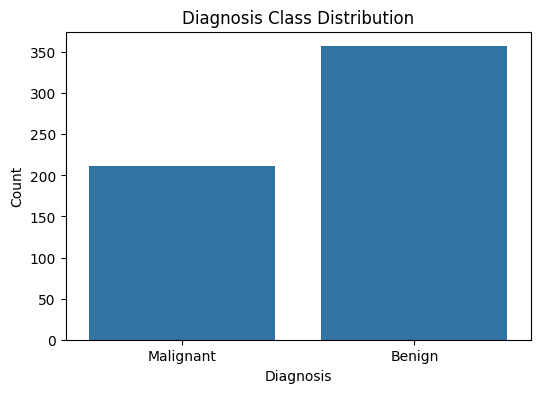

In [ ]:
# Display missing values
print("Missing Values:")
print(data.isnull().sum().sum())

# Display summary statistics
print("\nSummary Statistics:")
display(data.describe())

# Display feature dimensions
print("\nNumber of Rows:", data.shape[0])
print("Number of Features:", data.shape[1])

# Display class distribution
print("\nClass Distribution:")

class_names = {
    0: "Malignant",
    1: "Benign"
}

class_counts = pd.Series(y).map(class_names).value_counts()
print(class_counts)

# Plot class distribution
plt.figure(figsize=(6, 4))

sns.countplot(
    x=pd.Series(y).map(class_names)
)

plt.title("Diagnosis Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

plt.show()

# Task 3: Preprocess and Scale Features

* Select numerical features and drop non-informative identifiers (such as id).

* Apply StandardScaler to normalize feature magnitudes prior to graph distance calculation.

In [ ]:
# Select numerical features
X = data.select_dtypes(include=[np.number])

# Remove any identifier columns if present
X = X.drop(
    columns=["id"],
    errors="ignore"
)

# Handle missing values
X = X.fillna(X.mean())

# Apply StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original Feature Shape:", X.shape)
print("Scaled Feature Shape:", X_scaled.shape)

print("\nFirst 5 rows of scaled data:")
print(X_scaled[:5])

Original Feature Shape: (569, 30)
Scaled Feature Shape: (569, 30)

First 5 rows of scaled data:
[[ 1.09706398e+00 -2.07333501e+00  1.26993369e+00  9.84374905e-01
   1.56846633e+00  3.28351467e+00  2.65287398e+00  2.53247522e+00
   2.21751501e+00  2.25574689e+00  2.48973393e+00 -5.65265059e-01
   2.83303087e+00  2.48757756e+00 -2.14001647e-01  1.31686157e+00
   7.24026158e-01  6.60819941e-01  1.14875667e+00  9.07083081e-01
   1.88668963e+00 -1.35929347e+00  2.30360062e+00  2.00123749e+00
   1.30768627e+00  2.61666502e+00  2.10952635e+00  2.29607613e+00
   2.75062224e+00  1.93701461e+00]
 [ 1.82982061e+00 -3.53632408e-01  1.68595471e+00  1.90870825e+00
  -8.26962447e-01 -4.87071673e-01 -2.38458552e-02  5.48144156e-01
   1.39236330e-03 -8.68652457e-01  4.99254601e-01 -8.76243603e-01
   2.63326966e-01  7.42401948e-01 -6.05350847e-01 -6.92926270e-01
  -4.40780058e-01  2.60162067e-01 -8.05450380e-01 -9.94437403e-02
   1.80592744e+00 -3.69203222e-01  1.53512599e+00  1.89048899e+00
  -3.756119

# Task 4: Construct Pairwise Distance Matrix & Graph

* Compute pairwise Euclidean distance matrix across all scaled samples using scipy.spatial.distance.pdist or cdist.

* Represent the dataset as a weighted complete graph.

In [ ]:
# Compute pairwise Euclidean distances
distance_condensed = pdist(
    X_scaled,
    metric="euclidean"
)

# Convert to square distance matrix
distance_matrix = squareform(
    distance_condensed
)

print("Distance Matrix Shape:", distance_matrix.shape)

# Create weighted complete graph
G = nx.from_numpy_array(distance_matrix)

print("Number of Nodes:", G.number_of_nodes())
print("Number of Edges:", G.number_of_edges())

Distance Matrix Shape: (569, 569)
Number of Nodes: 569
Number of Edges: 161596


# Task 5: Compute the Minimum Spanning Tree (MST)

* Compute the MST using scipy.sparse.csgraph.minimum_spanning_tree or networkx.minimum_spanning_tree.

* Extract the resulting graph connections and weights.

In [ ]:
# Compute Minimum Spanning Tree
mst = nx.minimum_spanning_tree(
    G,
    weight="weight"
)

print("Minimum Spanning Tree created successfully.")

print("Number of MST Nodes:", mst.number_of_nodes())
print("Number of MST Edges:", mst.number_of_edges())

print("\nFirst 10 MST Edges:")

count = 0

for u, v, weight in mst.edges(data="weight"):

    print(
        "Edge:", u,
        "-", v,
        "Weight:", round(weight, 4)
    )

    count += 1

    if count == 10:
        break

Minimum Spanning Tree created successfully.
Number of MST Nodes: 569
Number of MST Edges: 568

First 10 MST Edges:
Edge: 0 - 77 Weight: 4.8299
Edge: 1 - 365 Weight: 2.2871
Edge: 2 - 535 Weight: 2.4515
Edge: 2 - 45 Weight: 2.6763
Edge: 2 - 77 Weight: 3.7056
Edge: 3 - 190 Weight: 7.871
Edge: 4 - 498 Weight: 2.8827
Edge: 5 - 47 Weight: 2.5029
Edge: 5 - 8 Weight: 2.6951
Edge: 5 - 105 Weight: 2.7035


# Task 6: Implement Graph-Based Clustering ($K=2$)

* Sort the edges of the MST in descending order by edge weight.
* Remove the largest $K - 1$ edge (1 largest edge for 2 clusters) to split the MST into 2 connected components.
* Assign final cluster labels based on the resulting component indices.


In [ ]:
# Create a copy of the MST
mst_cluster = mst.copy()

# Get all MST edges
mst_edges = list(
    mst_cluster.edges(data=True)
)

# Sort edges by weight in descending order
mst_edges_sorted = sorted(
    mst_edges,
    key=lambda x: x[2]["weight"],
    reverse=True
)

# Get the largest edge
largest_edge = mst_edges_sorted[0]

u = largest_edge[0]
v = largest_edge[1]
weight = largest_edge[2]["weight"]

print("Largest MST Edge:")
print("Edge:", u, "-", v)
print("Weight:", round(weight, 4))

# For K = 2, remove K-1 = 1 largest edge
mst_cluster.remove_edge(u, v)

print("\nLargest edge removed successfully.")

# Find connected components
components = list(
    nx.connected_components(mst_cluster)
)

print("\nNumber of Clusters:", len(components))

# Assign cluster labels
cluster_labels = np.zeros(
    len(X_scaled),
    dtype=int
)

for cluster_id, component in enumerate(components):
    for node in component:
        cluster_labels[node] = cluster_id

print("\nCluster Distribution:")
print(
    pd.Series(cluster_labels).value_counts()
)

print("\nFirst 20 Cluster Labels:")
print(cluster_labels[:20])

Largest MST Edge:
Edge: 461 - 503
Weight: 12.2999

Largest edge removed successfully.

Number of Clusters: 2

Cluster Distribution:
0    567
1      2
Name: count, dtype: int64

First 20 Cluster Labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


# Task 7: valuate MST Clustering Performance

Evaluate cluster assignment against ground truth labels using:

  *  Silhouette Score

  *  Adjusted Rand Index (ARI)

  *  Normalized Mutual Information (NMI)

In [ ]:
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# Silhouette Score
silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

# Adjusted Rand Index
ari = adjusted_rand_score(
    y,
    cluster_labels
)

# Normalized Mutual Information
nmi = normalized_mutual_info_score(
    y,
    cluster_labels
)

# Display results
print("MST Clustering Performance")
print("---------------------------")

print(
    "Silhouette Score:",
    round(silhouette, 4)
)

print(
    "Adjusted Rand Index (ARI):",
    round(ari, 4)
)

print(
    "Normalized Mutual Information (NMI):",
    round(nmi, 4)
)

MST Clustering Performance
---------------------------
Silhouette Score: 0.6607
Adjusted Rand Index (ARI): 0.0048
Normalized Mutual Information (NMI): 0.0102


# Task 8: Visualize MST and Graph-Based Clusters

* Select two representative features (e.g., mean radius vs. mean texture) for 2D plotting.
 * Plot 1: Unclustered standardized data points.
* Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data.
* Plot 3: Final clusters formed after cutting the $K - 1$ largest edge(s).

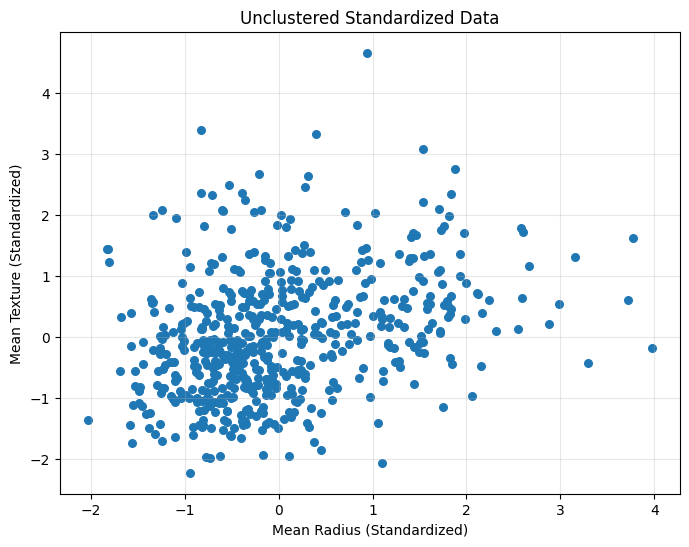

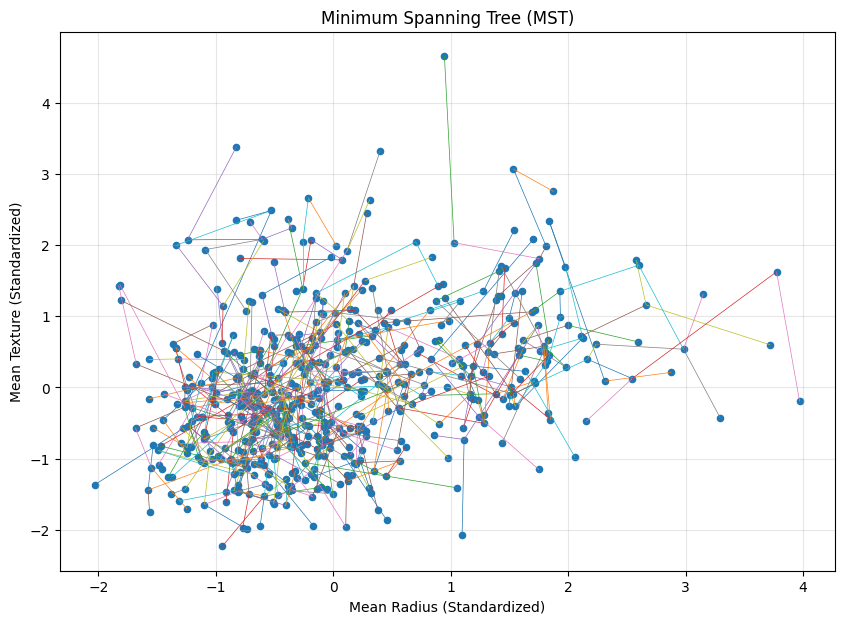

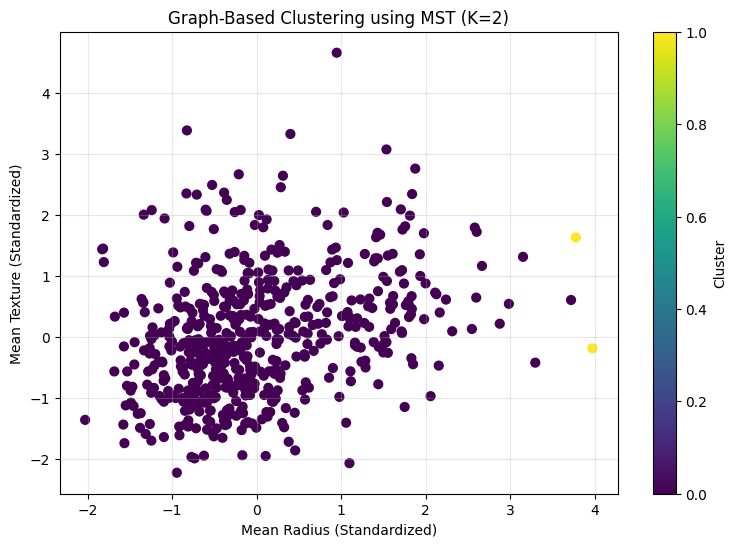

In [ ]:
# Select two representative features
# Feature 0 = mean radius
# Feature 1 = mean texture

feature1 = X_scaled[:, 0]
feature2 = X_scaled[:, 1]


# --------------------------------------------------
# Plot 1: Unclustered Standardized Data
# --------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    feature1,
    feature2,
    s=30
)

plt.xlabel("Mean Radius (Standardized)")
plt.ylabel("Mean Texture (Standardized)")
plt.title("Unclustered Standardized Data")

plt.grid(alpha=0.3)

plt.show()


# --------------------------------------------------
# Plot 2: Minimum Spanning Tree
# --------------------------------------------------

plt.figure(figsize=(10, 7))

# Plot all data points
plt.scatter(
    feature1,
    feature2,
    s=20
)

# Draw MST edges
for u, v, edge_data in mst.edges(data=True):

    plt.plot(
        [feature1[u], feature1[v]],
        [feature2[u], feature2[v]],
        linewidth=0.5
    )

plt.xlabel("Mean Radius (Standardized)")
plt.ylabel("Mean Texture (Standardized)")
plt.title("Minimum Spanning Tree (MST)")

plt.grid(alpha=0.3)

plt.show()


# --------------------------------------------------
# Plot 3: Final Graph-Based Clusters
# --------------------------------------------------

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    feature1,
    feature2,
    c=cluster_labels,
    s=40
)

plt.xlabel("Mean Radius (Standardized)")
plt.ylabel("Mean Texture (Standardized)")
plt.title("Graph-Based Clustering using MST (K=2)")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.grid(alpha=0.3)

plt.show()

# Conclusion

The experiment successfully demonstrated the implementation of Graph-Based Clustering using a Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was preprocessed, cleaned, and standardized before computing pairwise distances. The MST was generated, and by removing the largest edge(s), clusters representing tumor categories were obtained, evaluated using clustering metrics, and visualized.